# Session 3: Candidate routes and contrail exposure

Session 2 showed that persistent-contrail (PCR) conditions vary along a
trajectory, with ice supersaturation as the limiting factor. This session
asks how much the choice of route changes contrail exposure.

A fixed, systematic family of candidate routes between the same endpoints
(−10°, 45° → 10°, 55°) is evaluated with PCR on the same ERA5 data as
Session 2. The routes vary in:
- lateral deviation (perpendicular offset of 0, ±150 or ±300 km at mid-route)
- cruise altitude (10,000, 11,000 or 11,500 m)

The family is defined before looking at the results, so the routes
are not tuned to this particular humidity field.

**Change from Session 2:** routes fly at a realistic constant 230 m/s
(~830 km/h) rather than spreading 1,810 km over 6 hours (~84 m/s). Timing
matters for routing because it decides which atmosphere the aircraft meets.

**Assumptions:** no wind (ground speed = 230 m/s), constant altitude per
route (no climb or descent), departure at 2022-03-01 00:00 UTC, no humidity
scaling. Operational cost is represented only by extra distance flown.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from pycontrails import Flight
from pycontrails.datalib.ecmwf import ERA5ARCO
from pycontrails.models.pcr import PCR
from pycontrails.physics import thermo, units

results_dir = Path("..") / "results"
fig_dir = results_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Identical request to Session 2, so it reuses the same cached hourly files
era5_session3 = ERA5ARCO(
    time=("2022-03-01T00", "2022-03-01T06"),
    variables=["air_temperature", "specific_humidity"],
    pressure_levels=[200, 225, 250, 275, 300],
)
met_session3 = era5_session3.open_metdataset()
print(met_session3.data.sizes)


def check_met_box(met, lon_range, lat_range):
    """Count NaNs per hour in a lon/lat box; stop if any are present."""
    rows = []
    for t in met.data["time"].values:
        b = met.data.sel(time=t, longitude=slice(*lon_range), latitude=slice(*lat_range))
        rows.append({
            "time": pd.Timestamp(t),
            "air_temperature_nan": int(b["air_temperature"].isnull().sum().compute()),
            "specific_humidity_nan": int(b["specific_humidity"].isnull().sum().compute()),
        })
    df = pd.DataFrame(rows)
    assert df[["air_temperature_nan", "specific_humidity_nan"]].values.sum() == 0, \
        "Met data contains NaNs in this box"
    return df


LON_RANGE = (-15, 15)
LAT_RANGE = (40, 60)
print(check_met_box(met_session3, LON_RANGE, LAT_RANGE))

Frozen({'longitude': 1440, 'latitude': 721, 'level': 5, 'time': 7})
                 time  air_temperature_nan  specific_humidity_nan
0 2022-03-01 00:00:00                    0                      0
1 2022-03-01 01:00:00                    0                      0
2 2022-03-01 02:00:00                    0                      0
3 2022-03-01 03:00:00                    0                      0
4 2022-03-01 04:00:00                    0                      0
5 2022-03-01 05:00:00                    0                      0
6 2022-03-01 06:00:00                    0                      0


In [2]:
box = (
    met_session3.data[["air_temperature", "specific_humidity"]]
    .sel(longitude=slice(*LON_RANGE), latitude=slice(*LAT_RANGE))
    .load()
)
T_box = box["air_temperature"]
q_box = box["specific_humidity"]
p_box = xr.broadcast(T_box, box["level"] * 100.0)[1].transpose(*T_box.dims)  # Pa

rhi_field = xr.DataArray(
    thermo.rhi(q_box.values, T_box.values, p_box.values),
    coords=T_box.coords, dims=T_box.dims, name="rhi",
)
print("RHi field dims:", dict(rhi_field.sizes))
print("RHi range:", float(rhi_field.min()), "to", float(rhi_field.max()))
print("NaNs:", int(rhi_field.isnull().sum()))

print("\nFraction of the box that is ice-supersaturated (RHi > 1), by level and hour:")
issr_frac = (rhi_field > 1.0).mean(dim=["longitude", "latitude"]).to_pandas()
issr_frac.columns = [pd.Timestamp(t).strftime("%H:%M") for t in issr_frac.columns]
print(issr_frac.round(3))

print("\nMean temperature (K) by level and hour:")
T_mean = T_box.mean(dim=["longitude", "latitude"]).to_pandas()
T_mean.columns = issr_frac.columns
print(T_mean.round(1))

RHi field dims: {'longitude': 121, 'latitude': 81, 'level': 5, 'time': 7}
RHi range: 7.110155152419675e-05 to 1.4960697786529908
NaNs: 0

Fraction of the box that is ice-supersaturated (RHi > 1), by level and hour:
       00:00  01:00  02:00  03:00  04:00  05:00  06:00
level                                                 
200.0  0.000  0.000  0.000  0.000  0.000  0.000  0.000
225.0  0.095  0.091  0.085  0.077  0.081  0.081  0.081
250.0  0.124  0.131  0.137  0.140  0.143  0.147  0.149
275.0  0.158  0.163  0.177  0.186  0.180  0.181  0.174
300.0  0.169  0.181  0.203  0.211  0.206  0.194  0.197

Mean temperature (K) by level and hour:
            00:00       01:00       02:00       03:00       04:00       05:00  \
level                                                                           
200.0  216.500000  216.800003  217.000000  217.100006  217.199997  217.300003   
225.0  214.800003  214.899994  214.899994  215.100006  215.199997  215.300003   
250.0  216.800003  216.699997  216.

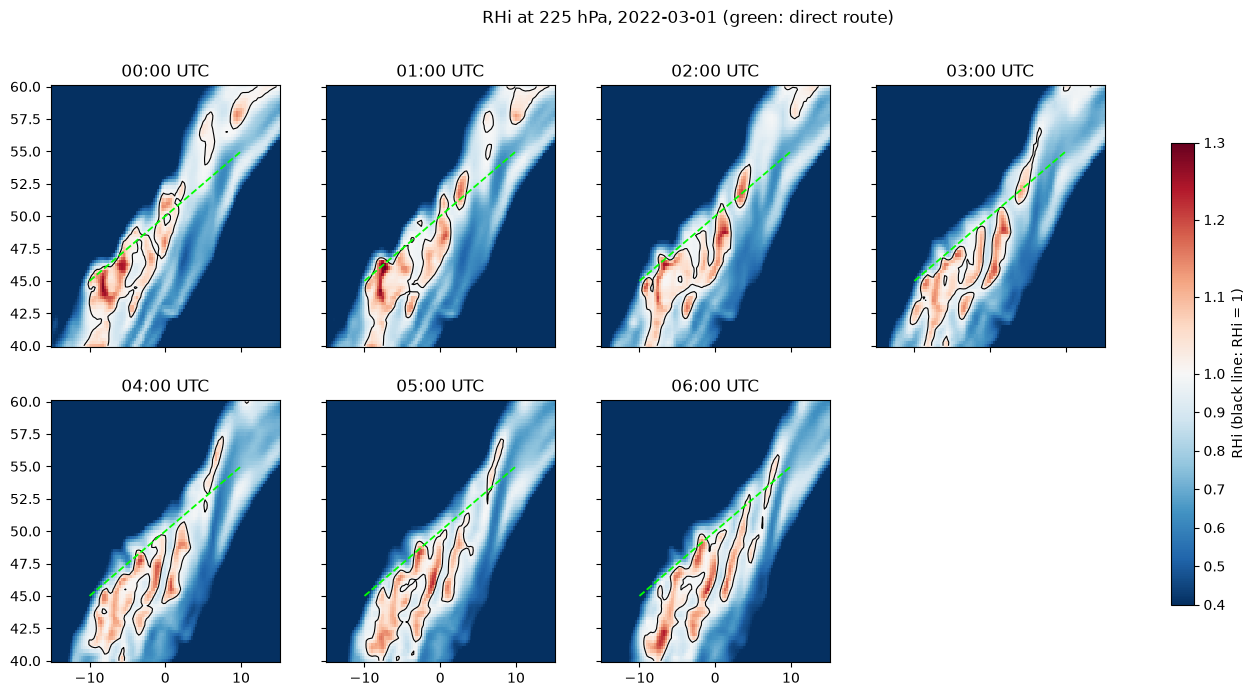

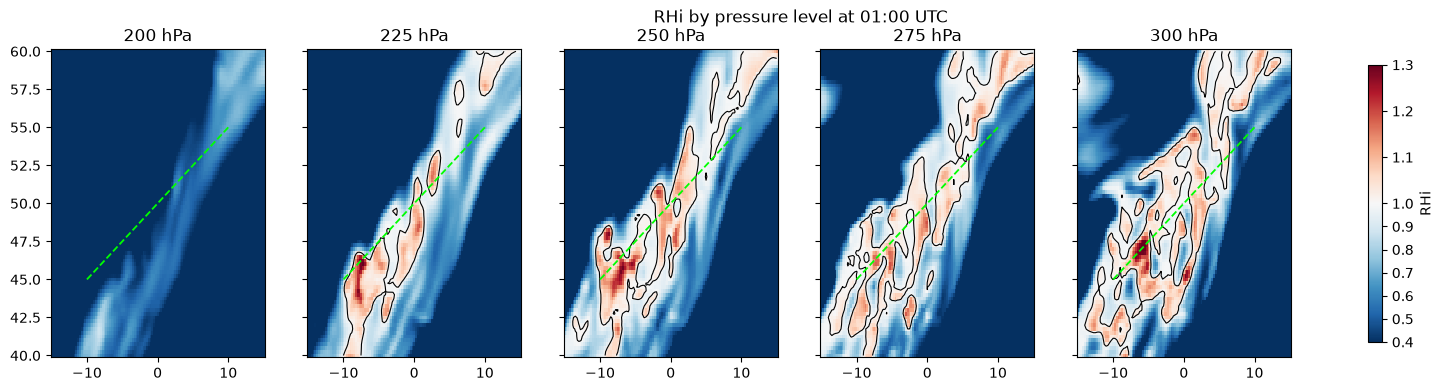

In [3]:
def plot_rhi_maps(level_hpa, times, fname):
    norm = TwoSlopeNorm(vmin=0.4, vcenter=1.0, vmax=1.3)
    fig, axes = plt.subplots(2, 4, figsize=(17, 7.5), sharex=True, sharey=True)
    for ax, t in zip(axes.flat, times):
        f = rhi_field.sel(level=level_hpa, time=t)
        mesh = ax.pcolormesh(f["longitude"], f["latitude"], f.T,
                             cmap="RdBu_r", norm=norm, shading="auto")
        ax.contour(f["longitude"], f["latitude"], f.T, levels=[1.0],
                   colors="k", linewidths=0.8)
        ax.plot([-10, 10], [45, 55], color="lime", linestyle="--", linewidth=1.3)
        ax.set_title(pd.Timestamp(t).strftime("%H:%M UTC"))
    for ax in axes.flat[len(times):]:
        ax.axis("off")
    fig.colorbar(mesh, ax=axes, shrink=0.8, label="RHi (black line: RHi = 1)")
    fig.suptitle(f"RHi at {level_hpa} hPa, 2022-03-01 (green: direct route)")
    fig.savefig(fig_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()


plot_rhi_maps(225, rhi_field["time"].values, "session3_rhi_225hPa_by_hour.png")

# Vertical structure at 01:00 (mid-way through a ~2 h direct flight)
t_mid = np.datetime64("2022-03-01T01:00")
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
norm = TwoSlopeNorm(vmin=0.4, vcenter=1.0, vmax=1.3)
for ax, lev in zip(axes, rhi_field["level"].values):
    f = rhi_field.sel(level=lev, time=t_mid)
    mesh = ax.pcolormesh(f["longitude"], f["latitude"], f.T, cmap="RdBu_r", norm=norm, shading="auto")
    ax.contour(f["longitude"], f["latitude"], f.T, levels=[1.0], colors="k", linewidths=0.8)
    ax.plot([-10, 10], [45, 55], color="lime", linestyle="--", linewidth=1.3)
    ax.set_title(f"{int(lev)} hPa")
fig.colorbar(mesh, ax=axes, shrink=0.9, label="RHi")
fig.suptitle("RHi by pressure level at 01:00 UTC")
fig.savefig(fig_dir / "session3_rhi_levels_0100UTC.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
R_EARTH_KM = 6371.0

def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * R_EARTH_KM * np.arcsin(np.sqrt(a))


ORIGIN = (-10.0, 45.0)   # (lon, lat)
DEST = (10.0, 55.0)
DEPARTURE = pd.Timestamp("2022-03-01 00:00")
CRUISE_SPEED_MS = 230.0
TIME_STEP_S = 60


def make_route(offset_km, altitude_m, name, n_shape=400):
    """
    Route from ORIGIN to DEST with a smooth sideways deviation.

    The path is built in a local flat (equirectangular) frame centred on the
    route's mid-latitude: a straight line plus a perpendicular bump of
    offset_km * sin(pi * s), where s goes 0 -> 1 along the route.
    offset_km > 0 bends to the left of travel (north-west), < 0 to the
    south-east. The aircraft flies at constant speed, so points are spaced
    by distance and times follow from distance / speed.
    """
    lat0 = np.radians(0.5 * (ORIGIN[1] + DEST[1]))
    kx, ky = 111.32 * np.cos(lat0), 110.57          # km per degree lon / lat
    x0, y0 = ORIGIN[0] * kx, ORIGIN[1] * ky
    x1, y1 = DEST[0] * kx, DEST[1] * ky
    dx, dy = x1 - x0, y1 - y0
    L = np.hypot(dx, dy)
    nx, ny = -dy / L, dx / L                        # unit normal, left of travel

    s = np.linspace(0.0, 1.0, n_shape)
    bump = offset_km * np.sin(np.pi * s)
    lon_dense = (x0 + s * dx + bump * nx) / kx
    lat_dense = (y0 + s * dy + bump * ny) / ky

    seg = haversine_km(lon_dense[:-1], lat_dense[:-1], lon_dense[1:], lat_dense[1:])
    cum_km = np.concatenate([[0.0], np.cumsum(seg)])
    duration_s = cum_km[-1] * 1000.0 / CRUISE_SPEED_MS

    t_s = np.arange(0.0, duration_s, TIME_STEP_S)
    if duration_s - t_s[-1] > 1.0:
        t_s = np.append(t_s, duration_s)
    d_km = t_s * CRUISE_SPEED_MS / 1000.0

    return Flight(
        longitude=np.interp(d_km, cum_km, lon_dense),
        latitude=np.interp(d_km, cum_km, lat_dense),
        altitude=np.full(len(t_s), float(altitude_m)),
        time=DEPARTURE + pd.to_timedelta(t_s, unit="s"),
        attrs={"flight_id": name},
    )


OFFSETS_KM = [-300, -150, 0, 150, 300]
ALTITUDES_M = [10000, 11000, 11500]

def route_name(offset_km, altitude_m):
    side = "DIR" if offset_km == 0 else ("NW" if offset_km > 0 else "SE")
    return f"{side}{abs(offset_km)}_{altitude_m}m"

routes = {
    route_name(o, a): make_route(o, a, route_name(o, a))
    for a in ALTITUDES_M for o in OFFSETS_KM
}

summary = []
for name, fl in routes.items():
    lon, lat = fl["longitude"], fl["latitude"]
    length = haversine_km(lon[:-1], lat[:-1], lon[1:], lat[1:]).sum()
    summary.append({
        "route": name,
        "points": len(fl),
        "length_km": round(length, 1),
        "duration_min": round((fl["time"][-1] - fl["time"][0]) / np.timedelta64(1, "m"), 1),
        "end_time": pd.Timestamp(fl["time"][-1]).strftime("%H:%M"),
        "pressure_hPa": round(float(units.m_to_pl(fl["altitude"][0])), 1),
        "lon_min": round(lon.min(), 2), "lon_max": round(lon.max(), 2),
        "lat_min": round(lat.min(), 2), "lat_max": round(lat.max(), 2),
    })
route_summary = pd.DataFrame(summary)
print(route_summary.to_string(index=False))
print("\nGreat-circle distance origin -> destination:",
      round(haversine_km(*ORIGIN, *DEST), 1), "km")

       route  points  length_km  duration_min end_time  pressure_hPa  lon_min  lon_max  lat_min  lat_max
SE300_10000m     146     1994.2         144.5    02:24         264.4    -10.0     10.0     45.0     55.0
SE150_10000m     137     1875.3         135.9    02:15         264.4    -10.0     10.0     45.0     55.0
 DIR0_10000m     133     1810.4         131.2    02:11         264.4    -10.0     10.0     45.0     55.0
NW150_10000m     132     1805.7         130.9    02:10         264.4    -10.0     10.0     45.0     55.0
NW300_10000m     136     1859.6         134.8    02:14         264.4    -10.0     10.0     45.0     55.0
SE300_11000m     146     1994.2         144.5    02:24         226.3    -10.0     10.0     45.0     55.0
SE150_11000m     137     1875.3         135.9    02:15         226.3    -10.0     10.0     45.0     55.0
 DIR0_11000m     133     1810.4         131.2    02:11         226.3    -10.0     10.0     45.0     55.0
NW150_11000m     132     1805.7         130.9    02:10 

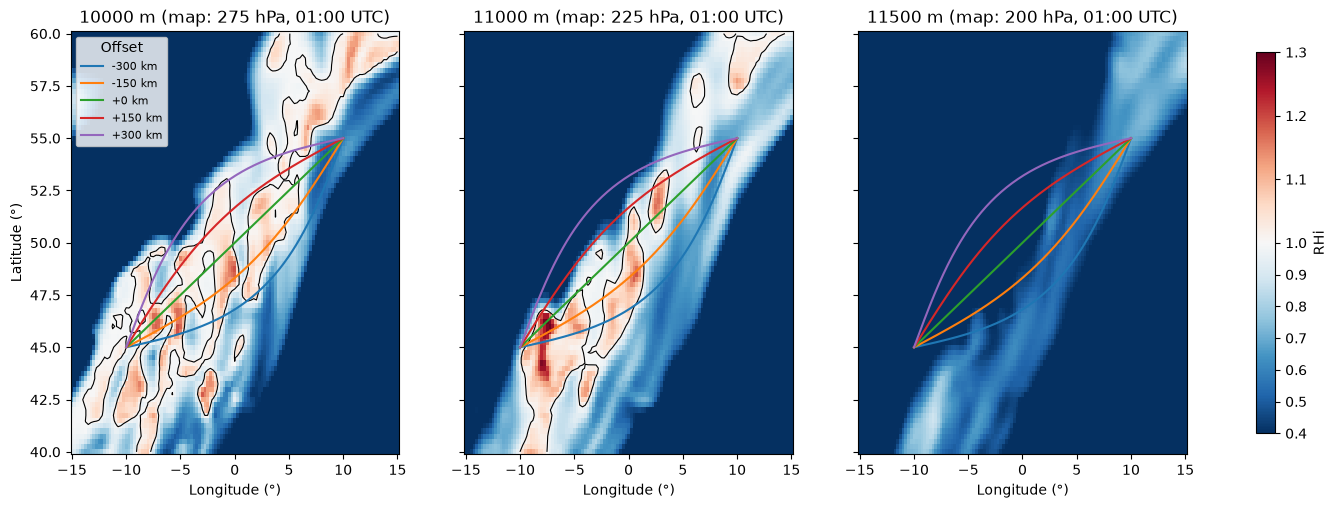

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
norm = TwoSlopeNorm(vmin=0.4, vcenter=1.0, vmax=1.3)
level_for_alt = {10000: 275, 11000: 225, 11500: 200}   # nearest met level

for ax, alt in zip(axes, ALTITUDES_M):
    f = rhi_field.sel(level=level_for_alt[alt], time=t_mid)
    mesh = ax.pcolormesh(f["longitude"], f["latitude"], f.T, cmap="RdBu_r", norm=norm, shading="auto")
    ax.contour(f["longitude"], f["latitude"], f.T, levels=[1.0], colors="k", linewidths=0.8)
    for o in OFFSETS_KM:
        fl = routes[route_name(o, alt)]
        ax.plot(fl["longitude"], fl["latitude"], linewidth=1.5, label=f"{o:+d} km")
    ax.set_title(f"{alt} m (map: {level_for_alt[alt]} hPa, 01:00 UTC)")
    ax.set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
axes[0].legend(title="Offset", fontsize=8)
fig.colorbar(mesh, ax=axes, shrink=0.9, label="RHi")
fig.savefig(fig_dir / "session3_candidate_routes.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# The ECMWF humidity-scaling warning is known and deliberate (baseline is
# unscaled). Silence that one message so it doesn't print 15 times.
warnings.filterwarnings("ignore", message="Met data appears to have originated from ECMWF")

along_track = {}
for name, fl in routes.items():
    # A fresh model per route: PCR cuts its met data down to the current
    # route's bounding box during eval, so a reused model would carry the
    # previous route's smaller box into the next one.
    model = PCR(met=met_session3)
    assert model.params["humidity_scaling"] is None
    out = model.eval(source=fl)

    df = pd.DataFrame({
        "route": name,
        "time": out["time"],
        "longitude": out["longitude"],
        "latitude": out["latitude"],
        "altitude_m": out["altitude"],
        "air_pressure_Pa": out["air_pressure"],
        "temperature_K": out["air_temperature"],
        "rh": out["rh"],
        "rhi": thermo.rhi(out["specific_humidity"], out["air_temperature"], out["air_pressure"]),
        "SAC": out["sac"],
        "ISSR": out["issr"],
        "PCR": out["pcr"],
    })
    leg = haversine_km(df["longitude"].values[:-1], df["latitude"].values[:-1],
                       df["longitude"].values[1:], df["latitude"].values[1:])
    df["leg_km"] = np.append(leg, 0.0)   # each leg attributed to its starting point
    along_track[name] = df
    print(f"{name:16s} done | NaN PCR: {int(df['PCR'].isna().sum())}")

along_track_all = pd.concat(along_track.values(), ignore_index=True)
assert along_track_all[["temperature_K", "rhi", "SAC", "ISSR", "PCR"]].isna().sum().sum() == 0, \
    "NaNs in route results: stop and inspect before interpreting"
print("\nAll routes evaluated with no missing values.")

C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:227: UserWarning: 
Met data appears to have originated from ECMWF and no humidity scaling is enabled. For ECMWF data, consider using one of: 
 - 'ConstantHumidityScaling'
 - 'ExponentialBoostHumidityScaling'
 - 'ExponentialBoostLatitudeCorrectionHumidityScaling'
 - 'HistogramMatching'
For example: 
>>> from pycontrails.models.humidity_scaling import ConstantHumidityScaling
>>> PCR(met=met, ..., humidity_scaling=ConstantHumidityScaling(rhi_adj=0.99))
  warnings.warn(
C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:227: UserWarning: 
Met data appears to have originated from ECMWF and no humidity scaling is enabled. For ECMWF data, consider using one of: 
 - 'ConstantHumidityScaling'
 - 'ExponentialBoostHumidityScaling'
 - 'ExponentialBoostLatitudeCorrectionHumidityScaling'
 - 'HistogramMatching'
For example: 
>>> from pycontrails.models.humidity_scaling impo

SE300_10000m     done | NaN PCR: 0
SE150_10000m     done | NaN PCR: 0
DIR0_10000m      done | NaN PCR: 0
NW150_10000m     done | NaN PCR: 0
NW300_10000m     done | NaN PCR: 0
SE300_11000m     done | NaN PCR: 0
SE150_11000m     done | NaN PCR: 0
DIR0_11000m      done | NaN PCR: 0
NW150_11000m     done | NaN PCR: 0
NW300_11000m     done | NaN PCR: 0
SE300_11500m     done | NaN PCR: 0
SE150_11500m     done | NaN PCR: 0
DIR0_11500m      done | NaN PCR: 0
NW150_11500m     done | NaN PCR: 0
NW300_11500m     done | NaN PCR: 0

All routes evaluated with no missing values.


In [7]:
REF = route_name(0, 11000)   # direct route at the Session 2 altitude

rows = []
for name, df in along_track.items():
    pcr, issr = df["PCR"] > 0, df["ISSR"] > 0
    rows.append({
        "route": name,
        "offset_km": int(name[2:].split("_")[0].replace("R", "") or 0)
                     * (1 if name.startswith("NW") else -1 if name.startswith("SE") else 0),
        "altitude_m": int(df["altitude_m"].iloc[0]),
        "length_km": df["leg_km"].sum(),
        "duration_min": (df["time"].iloc[-1] - df["time"].iloc[0]).total_seconds() / 60,
        "pcr_km": df.loc[pcr, "leg_km"].sum(),
        "issr_km": df.loc[issr, "leg_km"].sum(),
        "sac_fraction": df["SAC"].mean(),
        "rhi_max": df["rhi"].max(),
        "points_rhi_within_0.05": int(((df["rhi"] - 1).abs() < 0.05).sum()),
    })
route_metrics = pd.DataFrame(rows)
ref = route_metrics.set_index("route").loc[REF]
route_metrics["pcr_fraction"] = route_metrics["pcr_km"] / route_metrics["length_km"]
route_metrics["extra_km_vs_ref"] = route_metrics["length_km"] - ref["length_km"]
route_metrics["pcr_km_change_vs_ref"] = route_metrics["pcr_km"] - ref["pcr_km"]
route_metrics = route_metrics.sort_values(["altitude_m", "offset_km"]).reset_index(drop=True)

pd.set_option("display.width", 200)
print(route_metrics.round(3).to_string(index=False))

route_metrics.to_csv(results_dir / "session3_route_metrics.csv", index=False)
along_track_all.to_csv(results_dir / "session3_routes_along_track.csv", index=False)
print("\nSaved metrics and along-track results to", results_dir.resolve())

       route  offset_km  altitude_m  length_km  duration_min   pcr_km  issr_km  sac_fraction  rhi_max  points_rhi_within_0.05  pcr_fraction  extra_km_vs_ref  pcr_km_change_vs_ref
SE300_10000m       -300       10000   1994.180       144.506  703.797  703.797           1.0    1.194                      31         0.353          183.796               -96.602
SE150_10000m       -150       10000   1875.284       135.890 1200.598 1200.598           1.0    1.184                      35         0.640           64.900               400.198
 DIR0_10000m          0       10000   1810.384       131.187 1504.200 1504.200           1.0    1.162                      40         0.831            0.000               703.800
NW150_10000m        150       10000   1805.734       130.850 1228.200 1228.200           1.0    1.127                      59         0.680           -4.650               427.800
NW300_10000m        300       10000   1859.594       134.753  400.200  400.200           1.0    1.113    

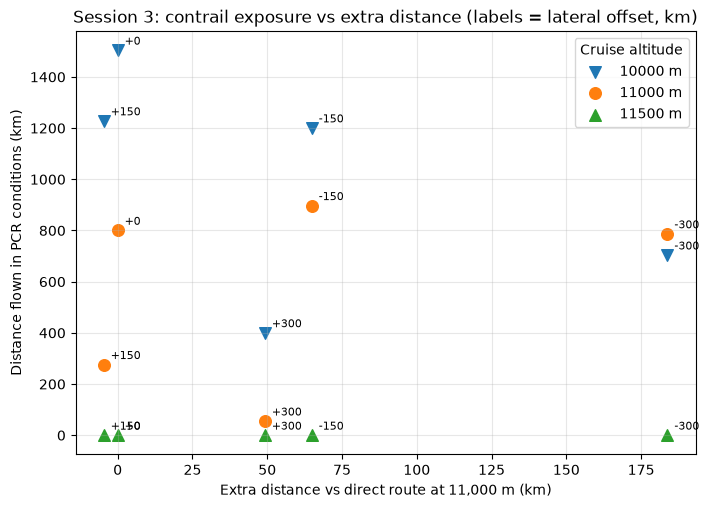

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))
markers = {10000: "v", 11000: "o", 11500: "^"}
for alt, grp in route_metrics.groupby("altitude_m"):
    ax.scatter(grp["extra_km_vs_ref"], grp["pcr_km"], marker=markers[alt], s=70, label=f"{alt} m")
    for _, r in grp.iterrows():
        ax.annotate(f"{r['offset_km']:+d}", (r["extra_km_vs_ref"], r["pcr_km"]),
                    textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.set_xlabel("Extra distance vs direct route at 11,000 m (km)")
ax.set_ylabel("Distance flown in PCR conditions (km)")
ax.set_title("Session 3: contrail exposure vs extra distance (labels = lateral offset, km)")
ax.legend(title="Cruise altitude")
ax.grid(alpha=0.3)
fig.savefig(fig_dir / "session3_exposure_vs_distance.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
import shutil

v1_files = [
    results_dir / "session3_route_metrics.csv",
    results_dir / "session3_routes_along_track.csv",
    fig_dir / "session3_candidate_routes.png",
    fig_dir / "session3_exposure_vs_distance.png",
]
for src in v1_files:
    dst = src.with_name(src.stem + "_v1_flatframe" + src.suffix)
    if src.exists() and not dst.exists():
        shutil.copy2(src, dst)
        print("Kept v1 copy:", dst.name)

route_metrics_v1 = route_metrics.copy()
along_track_v1 = along_track_all.copy()

# The message starts with a newline, so allow leading whitespace
warnings.filterwarnings("ignore", message=r"\s*Met data appears to have originated from ECMWF")

Kept v1 copy: session3_route_metrics_v1_flatframe.csv
Kept v1 copy: session3_routes_along_track_v1_flatframe.csv
Kept v1 copy: session3_candidate_routes_v1_flatframe.png
Kept v1 copy: session3_exposure_vs_distance_v1_flatframe.png


In [10]:
GC_KM = haversine_km(*ORIGIN, *DEST)

def lonlat_to_xyz(lon, lat):
    lon, lat = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(lat) * np.cos(lon),
                     np.cos(lat) * np.sin(lon),
                     np.sin(lat)], axis=-1)

def xyz_to_lonlat(v):
    lon = np.degrees(np.arctan2(v[..., 1], v[..., 0]))
    lat = np.degrees(np.arcsin(np.clip(v[..., 2], -1.0, 1.0)))
    return lon, lat

def fly_constant_speed(lon_dense, lat_dense, altitude_m, name):
    """Turn a densely sampled path into a Flight at CRUISE_SPEED_MS, one point per TIME_STEP_S."""
    seg = haversine_km(lon_dense[:-1], lat_dense[:-1], lon_dense[1:], lat_dense[1:])
    cum_km = np.concatenate([[0.0], np.cumsum(seg)])
    duration_s = cum_km[-1] * 1000.0 / CRUISE_SPEED_MS
    t_s = np.arange(0.0, duration_s, TIME_STEP_S)
    if duration_s - t_s[-1] > 1.0:
        t_s = np.append(t_s, duration_s)
    d_km = t_s * CRUISE_SPEED_MS / 1000.0
    return Flight(
        longitude=np.interp(d_km, cum_km, lon_dense),
        latitude=np.interp(d_km, cum_km, lat_dense),
        altitude=np.full(len(t_s), float(altitude_m)),
        time=DEPARTURE + pd.to_timedelta(t_s, unit="s"),
        attrs={"flight_id": name},
    )

def make_route_gc(offset_km, altitude_m, name, n_shape=400):
    """
    Great-circle route from ORIGIN to DEST with a smooth sideways deviation
    of offset_km * sin(pi * s), measured on the sphere perpendicular to
    the great circle. offset_km > 0 bends to the left of travel (north-west).
    """
    a, b = lonlat_to_xyz(*ORIGIN), lonlat_to_xyz(*DEST)
    omega = np.arccos(np.clip(a @ b, -1.0, 1.0))           # angle between endpoints
    s = np.linspace(0.0, 1.0, n_shape)[:, None]
    p = (np.sin((1 - s) * omega) * a + np.sin(s * omega) * b) / np.sin(omega)  # points on great circle
    n = np.cross(a, b)
    n /= np.linalg.norm(n)                                  # unit normal = left of travel
    delta = offset_km * np.sin(np.pi * s) / R_EARTH_KM      # sideways offset as an angle
    v = np.cos(delta) * p + np.sin(delta) * n
    lon_dense, lat_dense = xyz_to_lonlat(v)
    return fly_constant_speed(lon_dense, lat_dense, altitude_m, name)

def route_name_gc(offset_km, altitude_m):
    side = "GC" if offset_km == 0 else ("NW" if offset_km > 0 else "SE")
    return f"{side}{abs(offset_km)}_{altitude_m}m"

route_specs = {
    route_name_gc(o, a): {"offset_km": o, "altitude_m": a}
    for a in ALTITUDES_M for o in OFFSETS_KM
}
routes_v2 = {name: make_route_gc(sp["offset_km"], sp["altitude_m"], name)
             for name, sp in route_specs.items()}

check = []
for name, fl in routes_v2.items():
    lon, lat = fl["longitude"], fl["latitude"]
    check.append({
        "route": name,
        "points": len(fl),
        "length_km": round(haversine_km(lon[:-1], lat[:-1], lon[1:], lat[1:]).sum(), 1),
        "end_time": pd.Timestamp(fl["time"][-1]).strftime("%H:%M"),
        "start": (round(lon[0], 3), round(lat[0], 3)),
        "end": (round(lon[-1], 3), round(lat[-1], 3)),
    })
print(pd.DataFrame(check).to_string(index=False))
print("\nGreat-circle distance:", round(GC_KM, 1), "km")

       route  points  length_km end_time         start          end
SE300_10000m     140     1916.8    02:18 (-10.0, 45.0) (10.0, 55.0)
SE150_10000m     134     1830.3    02:12 (-10.0, 45.0) (10.0, 55.0)
  GC0_10000m     132     1800.1    02:10 (-10.0, 45.0) (10.0, 55.0)
NW150_10000m     134     1830.3    02:12 (-10.0, 45.0) (10.0, 55.0)
NW300_10000m     140     1916.8    02:18 (-10.0, 45.0) (10.0, 55.0)
SE300_11000m     140     1916.8    02:18 (-10.0, 45.0) (10.0, 55.0)
SE150_11000m     134     1830.3    02:12 (-10.0, 45.0) (10.0, 55.0)
  GC0_11000m     132     1800.1    02:10 (-10.0, 45.0) (10.0, 55.0)
NW150_11000m     134     1830.3    02:12 (-10.0, 45.0) (10.0, 55.0)
NW300_11000m     140     1916.8    02:18 (-10.0, 45.0) (10.0, 55.0)
SE300_11500m     140     1916.8    02:18 (-10.0, 45.0) (10.0, 55.0)
SE150_11500m     134     1830.3    02:12 (-10.0, 45.0) (10.0, 55.0)
  GC0_11500m     132     1800.1    02:10 (-10.0, 45.0) (10.0, 55.0)
NW150_11500m     134     1830.3    02:12 (-10.0,

In [12]:
def evaluate_routes(routes):
    """Run PCR on each route with a fresh model; return {name: along-track DataFrame}."""
    tables = {}
    for name, fl in routes.items():
        model = PCR(met=met_session3)          # fresh model: eval cuts met to this route's box
        assert model.params["humidity_scaling"] is None
        out = model.eval(source=fl)
        df = pd.DataFrame({
            "route": name,
            "time": out["time"],
            "longitude": out["longitude"],
            "latitude": out["latitude"],
            "altitude_m": out["altitude"],
            "air_pressure_Pa": out["air_pressure"],
            "temperature_K": out["air_temperature"],
            "rh": out["rh"],
            "rhi": thermo.rhi(out["specific_humidity"], out["air_temperature"], out["air_pressure"]),
            "SAC": out["sac"],
            "ISSR": out["issr"],
            "PCR": out["pcr"],
        })
        leg = haversine_km(df["longitude"].values[:-1], df["latitude"].values[:-1],
                           df["longitude"].values[1:], df["latitude"].values[1:])
        df["leg_km"] = np.append(leg, 0.0)
        tables[name] = df
    combined = pd.concat(tables.values(), ignore_index=True)
    n_nan = int(combined[["temperature_K", "rhi", "SAC", "ISSR", "PCR"]].isna().sum().sum())
    assert n_nan == 0, f"{n_nan} NaNs in route results: stop and inspect"
    print(f"Evaluated {len(tables)} routes, no missing values.")
    return tables


def compute_metrics(tables, specs, ref_name):
    rows = []
    for name, df in tables.items():
        pcr, issr = df["PCR"] > 0, df["ISSR"] > 0
        rows.append({
            "route": name,
            **specs[name],
            "pressure_hPa": df["air_pressure_Pa"].iloc[0] / 100.0,
            "length_km": df["leg_km"].sum(),
            "duration_min": (df["time"].iloc[-1] - df["time"].iloc[0]).total_seconds() / 60,
            "pcr_km": df.loc[pcr, "leg_km"].sum(),
            "issr_km": df.loc[issr, "leg_km"].sum(),
            "sac_fraction": df["SAC"].mean(),
            "rhi_max": df["rhi"].max(),
            "points_rhi_within_0.05": int(((df["rhi"] - 1).abs() < 0.05).sum()),
        })
    m = pd.DataFrame(rows)
    m["pcr_fraction"] = m["pcr_km"] / m["length_km"]
    m["extra_km_vs_gc"] = m["length_km"] - GC_KM
    m["pcr_km_change_vs_ref"] = m["pcr_km"] - m.set_index("route").loc[ref_name, "pcr_km"]
    return m.sort_values(["altitude_m", "offset_km"]).reset_index(drop=True)


SHOW_COLS = ["route", "offset_km", "altitude_m", "length_km", "extra_km_vs_gc",
             "pcr_km", "pcr_fraction", "pcr_km_change_vs_ref", "sac_fraction",
             "rhi_max", "points_rhi_within_0.05"]

In [13]:
along_track_v2 = evaluate_routes(routes_v2)
route_metrics_v2 = compute_metrics(along_track_v2, route_specs, ref_name="GC0_11000m")
print(route_metrics_v2[SHOW_COLS].round(3).to_string(index=False))

route_metrics_v2.to_csv(results_dir / "session3_route_metrics.csv", index=False)
pd.concat(along_track_v2.values(), ignore_index=True).to_csv(
    results_dir / "session3_routes_along_track.csv", index=False)
print("\nSaved v2 results.")

Evaluated 15 routes, no missing values.
       route  offset_km  altitude_m  length_km  extra_km_vs_gc   pcr_km  pcr_fraction  pcr_km_change_vs_ref  sac_fraction  rhi_max  points_rhi_within_0.05
SE300_10000m       -300       10000   1916.791         116.681  993.597         0.518               607.197           1.0    1.185                      41
SE150_10000m       -150       10000   1830.317          30.206 1310.999         0.716               924.599           1.0    1.189                      39
  GC0_10000m          0       10000   1800.110           0.000 1531.800         0.851              1145.400           1.0    1.134                      57
NW150_10000m        150       10000   1830.316          30.206  414.000         0.226                27.600           1.0    1.114                      33
NW300_10000m        300       10000   1916.790         116.680  510.599         0.266               124.199           1.0    1.121                      23
SE300_11000m       -300       

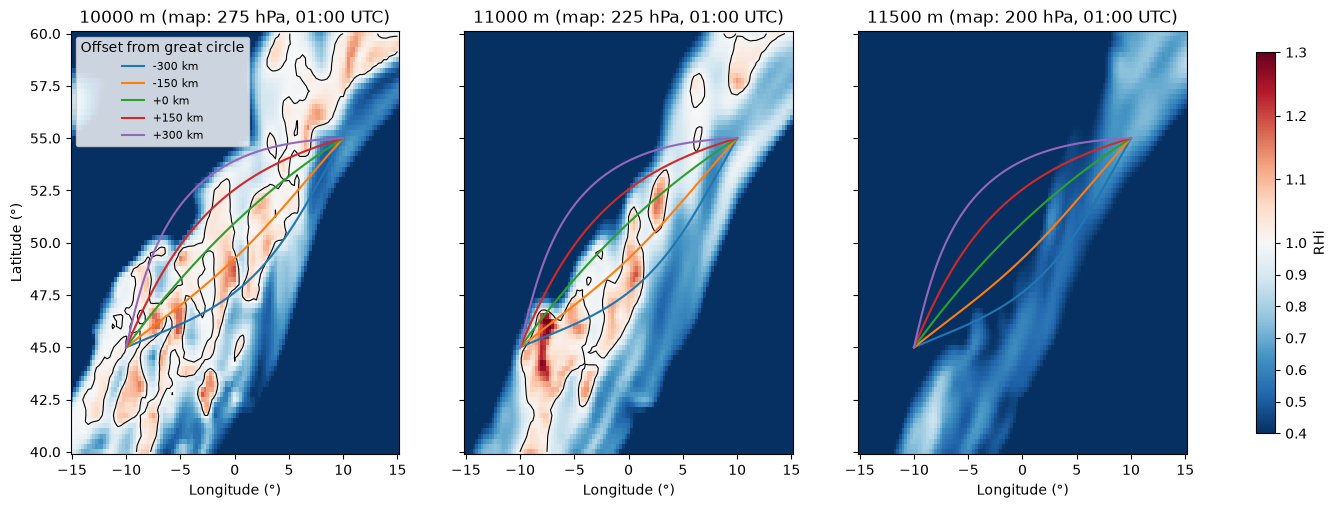

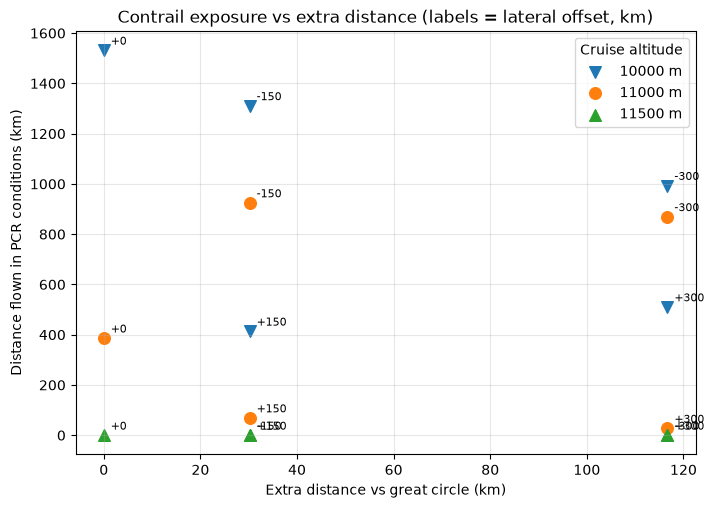

In [14]:
# Routes over the RHi field
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
norm = TwoSlopeNorm(vmin=0.4, vcenter=1.0, vmax=1.3)
for ax, alt in zip(axes, ALTITUDES_M):
    f = rhi_field.sel(level=level_for_alt[alt], time=t_mid)
    mesh = ax.pcolormesh(f["longitude"], f["latitude"], f.T, cmap="RdBu_r", norm=norm, shading="auto")
    ax.contour(f["longitude"], f["latitude"], f.T, levels=[1.0], colors="k", linewidths=0.8)
    for o in OFFSETS_KM:
        fl = routes_v2[route_name_gc(o, alt)]
        ax.plot(fl["longitude"], fl["latitude"], linewidth=1.5, label=f"{o:+d} km")
    ax.set_title(f"{alt} m (map: {level_for_alt[alt]} hPa, 01:00 UTC)")
    ax.set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
axes[0].legend(title="Offset from great circle", fontsize=8)
fig.colorbar(mesh, ax=axes, shrink=0.9, label="RHi")
fig.savefig(fig_dir / "session3_candidate_routes.png", dpi=150, bbox_inches="tight")
plt.show()

# Exposure vs extra distance
fig, ax = plt.subplots(figsize=(8, 5.5))
markers = {10000: "v", 11000: "o", 11500: "^"}
for alt, grp in route_metrics_v2.groupby("altitude_m"):
    ax.scatter(grp["extra_km_vs_gc"], grp["pcr_km"], marker=markers[alt], s=70, label=f"{alt} m")
    for _, r in grp.iterrows():
        ax.annotate(f"{int(r['offset_km']):+d}", (r["extra_km_vs_gc"], r["pcr_km"]),
                    textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.set_xlabel("Extra distance vs great circle (km)")
ax.set_ylabel("Distance flown in PCR conditions (km)")
ax.set_title("Contrail exposure vs extra distance (labels = lateral offset, km)")
ax.legend(title="Cruise altitude")
ax.grid(alpha=0.3)
fig.savefig(fig_dir / "session3_exposure_vs_distance.png", dpi=150, bbox_inches="tight")
plt.show()

Evaluated 24 routes, no missing values.
 altitude_m  pressure_hPa  pcr_km  pcr_fraction  rhi_max  points_rhi_within_0.05  sac_fraction
       9400       289.563  1587.0         0.882    1.194                      45           1.0
       9500       285.232  1573.2         0.874    1.182                      40           1.0
       9600       280.954  1518.0         0.843    1.156                      56           1.0
       9700       276.729  1352.4         0.751    1.113                      89           1.0
       9800       272.554  1311.0         0.728    1.100                      84           1.0
       9900       268.431  1449.0         0.805    1.115                      69           1.0
      10000       264.359  1531.8         0.851    1.134                      57           1.0
      10100       260.337  1490.4         0.828    1.158                      54           1.0
      10200       256.364  1421.4         0.790    1.180                      60           1.0
      1030

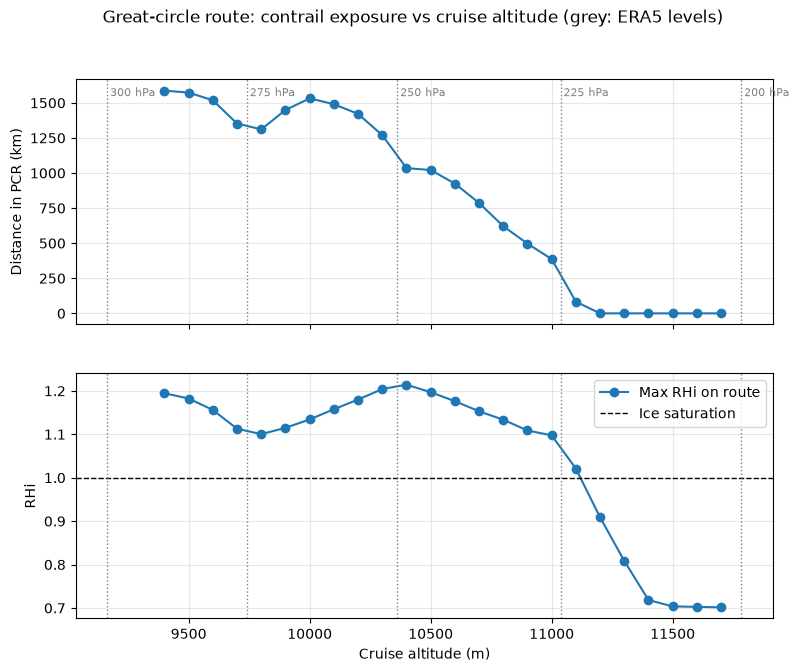

In [15]:
SWEEP_ALTS = list(range(9400, 11701, 100))   # all within the 300–200 hPa met levels
sweep_specs = {f"GC0_{a}m": {"offset_km": 0, "altitude_m": a} for a in SWEEP_ALTS}
sweep_routes = {n: make_route_gc(0, sp["altitude_m"], n) for n, sp in sweep_specs.items()}

sweep_tables = evaluate_routes(sweep_routes)
sweep_metrics = compute_metrics(sweep_tables, sweep_specs, ref_name="GC0_11000m")
print(sweep_metrics[["altitude_m", "pressure_hPa", "pcr_km", "pcr_fraction",
                     "rhi_max", "points_rhi_within_0.05", "sac_fraction"]].round(3).to_string(index=False))
sweep_metrics.to_csv(results_dir / "session3_altitude_sweep.csv", index=False)

# Altitude of each met level (ISA), to show where values are interpolated
level_alts = {int(l): float(units.pl_to_m(l)) for l in rhi_field["level"].values}

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(sweep_metrics["altitude_m"], sweep_metrics["pcr_km"], marker="o")
axes[0].set_ylabel("Distance in PCR (km)")
axes[1].plot(sweep_metrics["altitude_m"], sweep_metrics["rhi_max"], marker="o", label="Max RHi on route")
axes[1].axhline(1.0, color="k", linestyle="--", linewidth=1, label="Ice saturation")
axes[1].set_ylabel("RHi")
axes[1].set_xlabel("Cruise altitude (m)")
axes[1].legend()
for ax in axes:
    for lev, z in level_alts.items():
        ax.axvline(z, color="grey", linestyle=":", linewidth=1)
    ax.grid(alpha=0.3)
for lev, z in level_alts.items():
    axes[0].annotate(f"{lev} hPa", (z, 1.0), xycoords=("data", "axes fraction"),
                     xytext=(2, -12), textcoords="offset points", fontsize=8, color="grey")
fig.suptitle("Great-circle route: contrail exposure vs cruise altitude (grey: ERA5 levels)")
fig.savefig(fig_dir / "session3_altitude_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## Session 3 results

### Setup

Candidate routes from (−10°, 45°) to (10°, 55°) were evaluated with PCR on
ERA5 (2022-03-01, 200–300 hPa, no humidity scaling), departing 00:00 UTC
at a constant 230 m/s with no wind. A fixed, symmetric route family was
defined before any results were seen:

- **Lateral:** the great circle (1,800.1 km), plus smooth deviations of
  ±150 km (1,830.3 km, +1.7%) and ±300 km (1,916.8 km, +6.5%) at mid-route.
  NW = left of travel, SE = right.
- **Vertical:** 10,000 m (264 hPa), 11,000 m (226 hPa), 11,500 m (209 hPa),
  plus a fine sweep of the great-circle route from 9,400 to 11,700 m in
  100 m steps.

Flight times are 2 h 10 min to 2 h 18 min. SAC held at every point of every
route, so PCR exposure equals ISSR exposure throughout: **humidity alone
decides where persistent contrails can form.**

### The atmosphere

- Ice supersaturation increases downward through the 200–300 hPa layer.
  The box fraction with RHi > 1 is 0% at 200 hPa, ≈8–9% at 225 hPa,
  12–15% at 250, 16–19% at 275 and 17–21% at 300 hPa.
- 225 hPa is the coldest level (≈215 K) and 200 hPa is warmer (≈217 K). The
  tropopause lies between them, and the 200 hPa level is dry
  stratospheric air.
- At 225 hPa, the supersaturated air forms an elongated SW–NE band, lying
  almost along the route and drifting slowly south-east over the six hours.
  The air to the north-west is dry.

### Route comparison (distance flown in PCR conditions)

| Altitude | SE300 | SE150 | Great circle | NW150 | NW300 |
|---|---|---|---|---|---|
| 10,000 m | 993.6 km | 1,311.0 km | 1,531.8 km (85%) | 414.0 km | 510.6 km |
| 11,000 m | 869.4 km | 924.6 km | **386.4 km (21%)** | 69.0 km | 27.6 km |
| 11,500 m | 0 | 0 | 0 | 0 | 0 |
| Extra distance | +116.7 km | +30.2 km | 0 | +30.2 km | +116.7 km |

Reference: the great-circle route at 11,000 m (386.4 km in PCR, 21% of the route).

- **Altitude is the strongest lever.** At 11,500 m, every route has zero
  exposure, with maximum RHi only 0.70–0.71, far from the threshold.
  Dropping to 10,000 m roughly quadruples exposure on the great circle.
- **Lateral deviation works only towards the dry side.** At 11,000 m, a
  150 km north-west bend cuts exposure from 386.4 km to 69.0 km for
  +30.2 km (+1.7%) extra distance. Bending south-east more than doubles it.
- **Exposure doesn't change steadily with deviation.** At 10,000 m,
  NW300 (510.6 km) is worse than NW150 (414.0 km). Bigger detours are not
  automatically better.

### Altitude sweep (great-circle route)

Exposure is high and irregular below ≈10,300 m (1,270–1,590 km). It falls
steadily from 1,532 km at 10,000 m to 386.4 km at 11,000 m, and 82.8 km at
11,100 m. It is zero from 11,200 m upwards (maximum RHi 0.91 at 11,200 m,
≈0.70 at 11,500 m and above).

**Caveat:** the cut-off at 11,100–11,200 m lies between the 225 hPa
(≈11,040 m) and 200 hPa (≈11,780 m) ERA5 levels. There, temperature and
humidity are linearly interpolated between a moist tropospheric level and
a dry stratospheric one. The data supports "the moist layer ends somewhere
between ≈11,040 and ≈11,780 m". The precise cut-off altitude is an
artefact of interpolation and should not be over-interpreted. Points far
above the cut-off (e.g. 11,500 m+, RHi ≈ 0.70) are much less sensitive to
this than points near it.

### Robustness indications

The number of points within ±0.05 of RHi = 1 shows how fragile each result
is. On the great circle at 11,000 m, 33 of 132 points are near the
threshold. The NW300 route at 11,000 m has only 4, and the 11,500 m routes
have none. Low exposure and few near-threshold points together suggest a
choice likely to stay good under humidity error. This will be tested
explicitly in the uncertainty analysis.

### Method notes and corrections

- **Speed correction from Session 2.** Session 2's flight spread 1,810 km
  over 6 h (≈84 m/s). Flown at a realistic 230 m/s, the same straight line
  has 800.4 km in PCR instead of 316.5 km, because it crosses the
  supersaturated band at different times. Timing materially changes
  exposure, so Session 2's segment times should not be read as a real
  flight's.
- **Route geometry (v1 → v2).** The first route family (v1) was built as
  straight lines on a flat lon/lat map. That "direct" route (1,810.4 km) was
  not the shortest path: the great circle (1,800.1 km) bows north-west of
  it, which made NW and SE routes asymmetric in length. The family was
  rebuilt around the great circle (v2, reported above). This was a geometry
  correction, not a change based on PCR results. v1 outputs are kept as
  `*_v1_flatframe` files.
- The known ECMWF humidity-scaling warning is suppressed in this notebook
  to avoid repetition. Humidity scaling remains off (`humidity_scaling=None`,
  asserted for every model).

### Limitations

- One date, one departure time, one city pair. The supersaturated band
  happened to lie along the route, which favours large lateral and vertical
  effects.
- No wind. In reality, a band like this is often associated with the jet
  stream, which would change ground speed and therefore timing.
- Constant altitude per route, with no climb, descent or step changes.
- Operational cost is measured only as extra distance. Changing cruise
  altitude has a fuel cost that is not represented, so altitude changes
  appear "free" here, which they are not.
- PCR measures where persistent contrails can form, not their climate
  effect. It is used here as a proxy for contrail impact.
- ERA5 is known to under-represent ice supersaturation, and vertical
  resolution near the tropopause is limited to the 5 loaded levels.